In [1]:
import math
import matplotlib.pyplot as plt
import keras
import pandas as pd
import numpy as np
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout
from keras.layers import *
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv('ETH-USD.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-08-07,2.831620,3.536610,2.521120,2.772120,2.772120,164329.0
1,2015-08-08,2.793760,2.798810,0.714725,0.753325,0.753325,674188.0
2,2015-08-09,0.706136,0.879810,0.629191,0.701897,0.701897,532170.0
3,2015-08-10,0.713989,0.729854,0.636546,0.708448,0.708448,405283.0
4,2015-08-11,0.708087,1.131410,0.663235,1.067860,1.067860,1463100.0


In [3]:
df = df.dropna()
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-08-07,2.831620,3.536610,2.521120,2.772120,2.772120,1.643290e+05
1,2015-08-08,2.793760,2.798810,0.714725,0.753325,0.753325,6.741880e+05
2,2015-08-09,0.706136,0.879810,0.629191,0.701897,0.701897,5.321700e+05
3,2015-08-10,0.713989,0.729854,0.636546,0.708448,0.708448,4.052830e+05
4,2015-08-11,0.708087,1.131410,0.663235,1.067860,1.067860,1.463100e+06
...,...,...,...,...,...,...,...
2275,2021-10-29,4288.686523,4455.735352,4271.707520,4414.746582,4414.746582,2.296764e+10
2276,2021-10-30,4414.243652,4426.848633,4252.494141,4325.650391,4325.650391,1.461549e+10
2277,2021-10-31,4322.744141,4394.449707,4179.016113,4288.074219,4288.074219,1.749816e+10
2278,2021-11-01,4288.217285,4377.322266,4160.966797,4324.626953,4324.626953,1.798529e+10


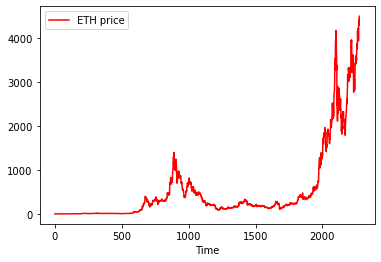

In [79]:
price = df['Close'].values
x= np.arange(0,len(price),1)
plt.plot(x,price, c='r', label = 'ETH price')
plt.xlabel('Time')
plt.legend()
plt.show();

In [102]:
limit = 1800
training_set = df.iloc[:limit, [1,2,3,4,6]].values
test_set = df.iloc[limit:, [1,2,3,4,6]].values

In [103]:
# Feature Scaling
sc = MinMaxScaler(feature_range = (0, 1))
training_set_scaled = sc.fit_transform(training_set[:,[0,1,2,3,4]])
# Creating a data structure with 60 time-steps and 1 output
X_train = []
y_train = []
for i in range(150, limit):
    X_train.append(training_set_scaled[i-150:i, [0,1,2,3,4]])
    y_train.append(training_set_scaled[i,3])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 5))

In [104]:
model = Sequential()
#Adding the first LSTM layer and some Dropout regularisation
model.add(LSTM(units = 5, return_sequences = True, input_shape = (X_train.shape[1], 5)))
model.add(Dropout(0.2))
# Adding a second LSTM layer and some Dropout regularisation
model.add(LSTM(units = 60, return_sequences = True))
model.add(Dropout(0.2))
# Adding a third LSTM layer and some Dropout regularisation
model.add(LSTM(units = 60, return_sequences = True))
model.add(Dropout(0.2))
model.add(LSTM(units = 60, return_sequences = True))
model.add(Dropout(0.2))
model.add(LSTM(units = 60, return_sequences = True))
model.add(Dropout(0.2))
# Adding a fourth LSTM layer and some Dropout regularisation
model.add(LSTM(units = 60))
model.add(Dropout(0.2))
# Adding the output layer
model.add(Dense(units = 25))
model.add(Dense(units = 1))

# Compiling the RNN
model.compile(optimizer = 'adam', loss = 'mean_squared_error')

# Fitting the RNN to the Training set
model.fit(X_train, y_train, epochs = 30, batch_size = 300)

Epoch 1/30
6/6 [==============================] - 21s 2s/step - loss: 0.0310
Epoch 2/30
6/6 [==============================] - 9s 2s/step - loss: 0.0156
Epoch 3/30
6/6 [==============================] - 9s 2s/step - loss: 0.0088
Epoch 4/30
6/6 [==============================] - 10s 2s/step - loss: 0.0063
Epoch 5/30
6/6 [==============================] - 11s 2s/step - loss: 0.0059
Epoch 6/30
6/6 [==============================] - 10s 2s/step - loss: 0.0048
Epoch 7/30
6/6 [==============================] - 11s 2s/step - loss: 0.0049
Epoch 8/30
6/6 [==============================] - 10s 2s/step - loss: 0.0047
Epoch 9/30
6/6 [==============================] - 10s 2s/step - loss: 0.0046
Epoch 10/30
6/6 [==============================] - 10s 2s/step - loss: 0.0043
Epoch 11/30
6/6 [==============================] - 11s 2s/step - loss: 0.0038
Epoch 12/30
6/6 [==============================] - 10s 2s/step - loss: 0.0040
Epoch 13/30
6/6 [==============================] - 9s 2s/step - loss: 0.003

In [105]:
dataset_train = df.iloc[:limit, [1,2,3,4,6]]
dataset_test = df.iloc[limit:, [1,2,3,4,6]]
dataset_total = pd.concat((dataset_train, dataset_test), axis = 0)
inputs = dataset_total[len(dataset_total) - len(dataset_test) - 150:].values
inputs = sc.transform(inputs)
X_test = []
for i in range(150, 600):
    X_test.append(inputs[i-150:i, [0,1,2,3,4]])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 5))

In [106]:
predicted_stock_price = model.predict(X_test)
print(predicted_stock_price.shape)
predicted_stock_price = predicted_stock_price.flatten()
#predicted_stock_price

(450, 1)


In [107]:
result = np.array([predicted_stock_price,
                      np.zeros((450,1)).flatten(),
                      np.zeros((450,1)).flatten(),
                      np.zeros((450,1)).flatten(),
                      np.zeros((450,1)).flatten()])

In [108]:
predicted_stock_price = sc.inverse_transform(result.T)

In [109]:
predicted_stock_price = predicted_stock_price[:,0]
#predicted_stock_price

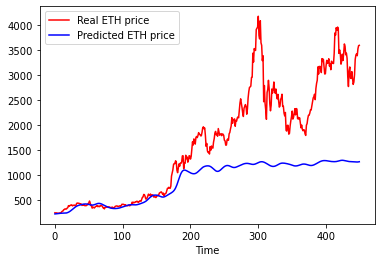

In [110]:
x= np.arange(0,450,1)
plt.plot(x,test_set[0:450,3], c='r', label = 'Real ETH price')
plt.plot(x,predicted_stock_price, c='b', label = 'Predicted ETH price')
plt.xlabel('Time')
plt.legend()
plt.show();

Predictions are accurate for "low" price variation, but very difficult when the evolution is more vertical.

In [111]:
np.corrcoef(test_set[0:450,3],predicted_stock_price.reshape(test_set[0:450,3].shape))

array([[1.        , 0.90688676],
       [0.90688676, 1.        ]])